# Intro

## 1.1. Contexte
Dans un contexte bancaire où la rapidité et la précision des décisions d’octroi de crédit sont cruciales, ActivBank souhaite optimiser son processus d’évaluation des biens immobiliers. L’objectif est d’automatiser partiellement et de fiabiliser cette étape clé afin de faciliter la décision d’acceptation ou de refus d’un prêt hypothécaire. En effet, lors d'une demande de prêt hypothécaire, Une estimation du bien convoité par le client est obligatoire, car ce bien servira de garantie au prêt en cas de problèeme de remboursement. La banque doit donc évaluer au plus proche la valeur du bien, si la valeur estimée est plus petite que le montant de la demande du prêt, la banque ne peut pas préter l'argent.
## 1.2. Le besoin 
Le besoin principal est de prédire la valeur de revente d’un bien immobilier à partir de ses caractéristiques. l'idée est d'évaluer le prix des biens, afin de pouvoir faciliter et partiellement automatiser l'octroi de prêt immobilier. Il s’agit d’un problème de régression où la variable cible est une valeur numérique continue exprimée en dollars. Cette estimation permettra d’évaluer la garantie offerte par le bien en cas de défaut de remboursement.
## 1.3. L'utilité 
La prédiction servira à automatiser partiellement l’estimation de la valeur d’un bien lors de la constitution des dossiers de prêt immobilier. Elle facilitera ainsi l’évaluation du risque associé à chaque demande de crédit. Pour des questions éthiques et légales, le refus d'un prêt doit forcément être effectuée par un être humain et ne peut pas être effectuée par une IA. Les demandes de prêts seront donc divisées en trois piles:
1. les cas clairs de refus ==> ces dossiers seront recontrôlés par un humains
2. La zone grise ==> ces dossiers seront traités par des humains
3. Les cas clairs d'autorisation ==> le dossier est accepté automatiquement.
## 1.4. La plus-value 
L’automatisation de cette estimation permettra un gain de temps significatif dans le traitement des demandes, une meilleure précision dans l’évaluation des garanties, et une réduction des risques pour la banque. Elle permettra également d’objectiver les décisions, réduisant les biais et augmentant la transparence du processus. En gros, cela permettra d'estimer les biens plus vites et à moindre coûts, on ne passera plus par un agent immobilier qui doit se déplacer en fonction de son planning, l'évaluation sera donc immédiate. De plus on réduire les risques de coruptions ou de manque d'objectivités des agents immobiliers.
## 1.5. Comment sera mis en place le modèle ?
Le modèle sera entraîné sur des données réelles de ventes immobilières issues de différentes sources (plateformes immobilières, bases internes à la banque, données fiscales et cadastrales). Il sera intégré au processus de constitution des dossiers sous forme de prédiction batch. Un ensemble de vérifications et de post-traitements garantira la fiabilité des résultats. Les performances du modèle seront suivies en continu via des comparaisons aux ventes réelles postérieures.
## 1.6. Les variables
Pour la mise en œuvre de notre modèle de prédiction du prix de vente d’un bien immobilier, nous avons sélectionné un ensemble restreint mais pertinent de variables, en tenant compte à la fois de leur corrélation statistique avec le prix et de leur valeur ajoutée métier. Ces variables permettent de capter des dimensions essentielles de l’évaluation immobilière, souvent prises en compte de manière intuitive par les experts du domaine.
OverallQual (qualité globale de la maison)
Il s'agit de la variable la plus corrélée avec le prix de vente. Elle traduit une appréciation générale de la qualité de construction et des finitions. D’un point de vue métier, cette variable synthétise plusieurs critères techniques (matériaux, finitions, état général) que les acheteurs prennent en compte. Elle est donc essentielle pour estimer la valeur perçue du bien.
GrLivArea (surface habitable hors sous-sol)
La surface habitable est l’un des premiers indicateurs utilisés par les agents immobiliers et les acheteurs pour comparer des biens. Cette variable est un excellent indicateur de la taille réelle utilisable du logement et a logiquement une forte influence sur le prix.
TotalBsmtSF (surface totale du sous-sol)
Bien que le sous-sol ne soit pas toujours pris en compte dans la surface habitable, il constitue un espace supplémentaire valorisé, notamment lorsqu’il est aménagé. Cette variable permet de capturer cette surface « invisible » mais souvent prise en compte dans les négociations immobilières. Elle est moins redondante que d’autres variables similaires, tout en ajoutant de la granularité à l’estimation.
YearBuilt (année de construction)
Cette variable capte l’ancienneté du bien et reflète la qualité de l’infrastructure initiale, ainsi que le style architectural. Dans le métier, il est connu que certaines maisons anciennes, bien situées et bien conservées, peuvent se vendre à un prix supérieur à des constructions récentes. Elle ajoute donc un axe temporel important dans l’analyse.
Neighborhood (quartier)
L’emplacement est l’un des facteurs les plus déterminants dans la valorisation d’un bien. Cette variable catégorielle, une fois encodée correctement, permet de distinguer les écarts de prix dus aux différences socio-économiques, à l’attractivité locale, aux services à proximité ou encore à la réputation du quartier. C’est une variable à très fort pouvoir explicatif.

# Imports

Cette section permet d'importer toutes les librairies utilisées dans ce Jupyter Notebook. Avant de commencer, il est préférable de créer un environnement virtuel, puis installer les librairies mentionnées dans le fichier `requirements.txt`.

Commandes à exécuter (à la racine du projet) :
1) *python -m venv .venv*
2) *.venv\Scripts\activate*
3) *pip install -r requirements.txt*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')

import seaborn as sns
import scipy.stats as stats
from statsmodels.graphics.gofplots import qqplot
from statsmodels.graphics.gofplots import ProbPlot
import statsmodels.api as sm

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Lasso
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

from xgboost import XGBRegressor

import optuna
from optuna.visualization import plot_slice

import mlflow
from mlflow.models import infer_signature

# Données

Description des données

Analysez les données en votre possession

Emettez des hypothèses sur les données qui possèdent le plus d’information selon vous. 

Ophélie

## Récupération et normalisation

Les jeux de données d'entraînement et de test sont chargés depuis les fichiers CSV fournis par Kaggle. La colonne `Id` est utilisée comme index car elle sert uniquement d’identifiant et ne contient aucune autre information utile.

In [3]:
train_raw = pd.read_csv('Data/train.csv', index_col = 'Id')
validation_raw = pd.read_csv('Data/test.csv', index_col = 'Id')

Visualisation de la distribution de la variable cible `SalePrice` à l’aide d’un histogramme avec une courbe de densité (KDE). Cette étape permet de détecter visuellement si la variable suit une distribution normale ou présente une asymétrie (skewness), ce qui peut influencer le choix des transformations futures.

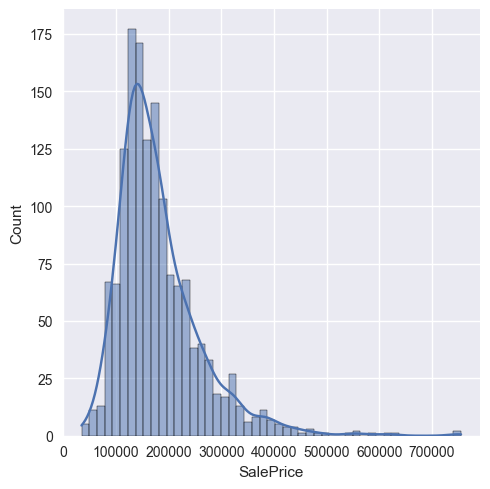

In [4]:
ax = sns.displot(data = train_raw['SalePrice'], kde=True)
plt.show()

Utilisation du test de Shapiro-Wilk pour évaluer statistiquement si la variable `SalePrice` suit une distribution normale.

**Hypothèse nulle (H₀)** : la variable suit une loi normale. Si la p-valeur < α (0.05), on rejette H₀ ⇒ `SalePrice` n’est pas normalement distribuée.

La normalité est une hypothèse souvent utile pour certains modèles ou certaines techniques de transformation, d’où l’intérêt de la tester formellement.

Le QQ-Plot (Quantile-Quantile plot) compare ensuite les quantiles de la distribution observée (`SalePrice`) à ceux d’une distribution normale théorique. Si les points suivent la ligne diagonale, cela suggère une distribution proche de la normale. S’ils dévient, cela confirme une asymétrie ou des valeurs extrêmes. Ce graphique complète le test de Shapiro-Wilk par une évaluation visuelle.

The assocated p-value is : 3.2061412312021656e-33
With a threshold α = 0.05, we reject the null hypothesis


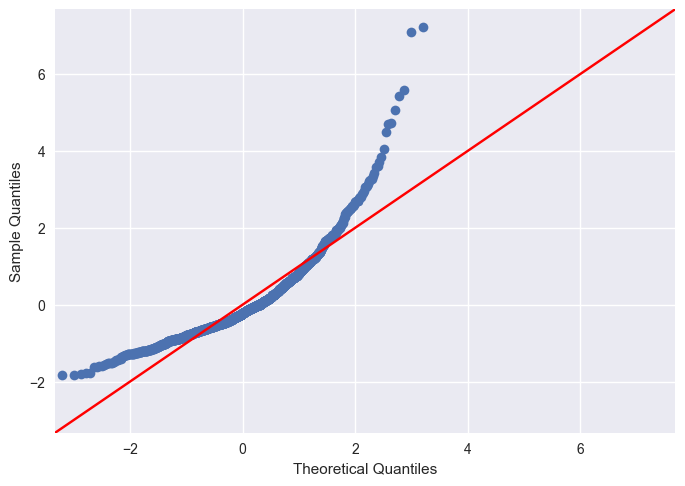

In [5]:
alpha = 0.05
W, p = stats.shapiro(train_raw['SalePrice'])

print('The assocated p-value is : ' + str(p))

if p < alpha : 
    print('With a threshold α = ' + str(alpha) + ', we reject the null hypothesis')
else : 
    print('With a threshold α = ' + str(alpha) + ', we fail to reject the null hypothesis')
    
qqplot(train_raw['SalePrice'], dist = stats.distributions.norm, fit = True, line = '45')
plt.show()

Le QQ-Plot montre une déviation importante des points par rapport à la diagonale (surtout dans les quantiles supérieurs), ce qui confirme une asymétrie à droite (right skew) typique des prix de vente. Cela implique que la variable cible `SalePrice` n’est pas normalement distribuée.

Nouvelle évaluation afin de savoir si la distribution suit une "log-normale" (si log(`SalePrice`) suit une normale). Ce deuxième QQ-Plot montre une bien meilleure linéarité, suggérant que la transformation logarithmique est pertinente pour réduire l’asymétrie.

Malgré cette correction, certains valeurs extrêmes émergent encore (sur la partie supérieure). Une analyse appronfondie de ces valeurs sera réalisée dans une prochaine section.

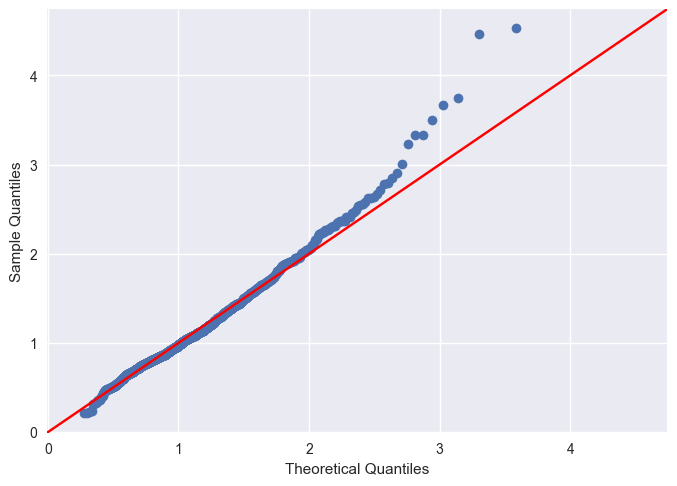

In [6]:
qqplot(train_raw['SalePrice'], dist = stats.distributions.lognorm, fit = True, line = '45')
plt.show()

La transformation `log1p(x)` (log(1 + x)) est utilisée pour rendre la distribution plus symétrique et proche de la normale pour notre variable cible. L’ajout de 1 avec log1p est une mesure de précaution pour éviter les erreurs log(0), même si dans ce jeu de données `SalePrice` est toujours > 0.

Un nouvel histogramme permet de confirmer visuellement que la distribution de la variable transformée est nettement plus symétrique. Cela appuie la validité de la transformation appliquée et justifie son utilisation.

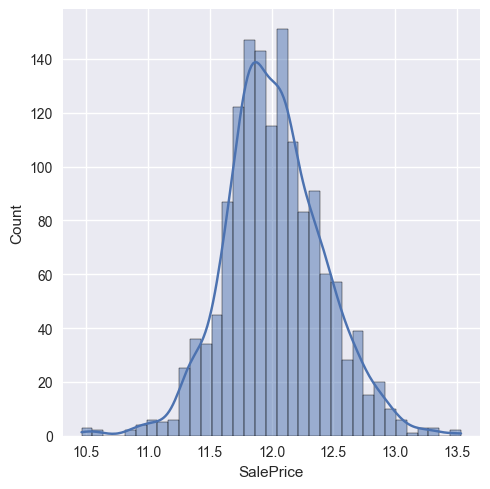

In [7]:
target = np.log1p(train_raw['SalePrice'])

# distribution plot
ax = sns.displot(data = target, kde=True)
plt.show()

## Traitement des données manquantes

La séparation des variables en trois catégories (qualitatives, quantitatives, et temporelles) est une étape importante pour appliquer des traitements appropriés à chaque type. Cette étape permettra un prétraitement cohérent par la suite.

Les jeux d'entraînement et de validation sont concaténés pour appliquer les mêmes traitements de nettoyage à l’ensemble des données. Cela évite de créer des incohérences entre les deux ensembles, notamment pour le traitement des valeurs manquantes.

In [8]:
qualitative = ['MSSubClass', 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
              'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
              'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
              'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
              'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
              'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
              'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageFinish', 
              'GarageCars', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
              'SaleType', 'SaleCondition', 'MoSold']

quantitative = ['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'MasVnrArea', 'BsmtFinSF1',  
               'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 
               'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 
               'PoolArea', 'MiscVal']

date = ['YearBuilt', 'YearRemodAdd', 'YrSold', 'GarageYrBlt']

In [9]:
data_raw = pd.concat([train_raw, validation_raw])

Avant de traiter les valeurs manquantes, il est essentiel de les identifier visuellement. Cette fonction permet :
- de détecter facilement quelles colonnes contiennent des données manquantes
- de quantifier l’importance du problème pour chaque variable

Toutes les valeurs manquantes ne doivent pas être traitées de la même façon. Il faut comprendre le sens de l'absence d'information.

Exemple :
- PoolArea = 0 → probablement pas de piscine (valeur informative)
- PoolQC = NaN → probablement une information manquante sur la qualité si la piscine existe

Dans ce contexte, on distingue deux grands cas :
- NaN = absence réelle
- NaN = donnée manquante

L’analyse visuelle des colonnes manquantes est donc une étape exploratoire clé pour décider de la meilleure stratégie d’imputation, en tenant compte du contexte métier de chaque variable.

In [10]:
# Plot des valeurs manquantes
def plot_missing(data):

    missing = data.isnull().sum()
    missing = missing[missing > 0]
    
    if missing.empty:
        print('No missing values')
    else :
        missing.sort_values(inplace=True)
        missing.plot.bar()
    
        plt.show()

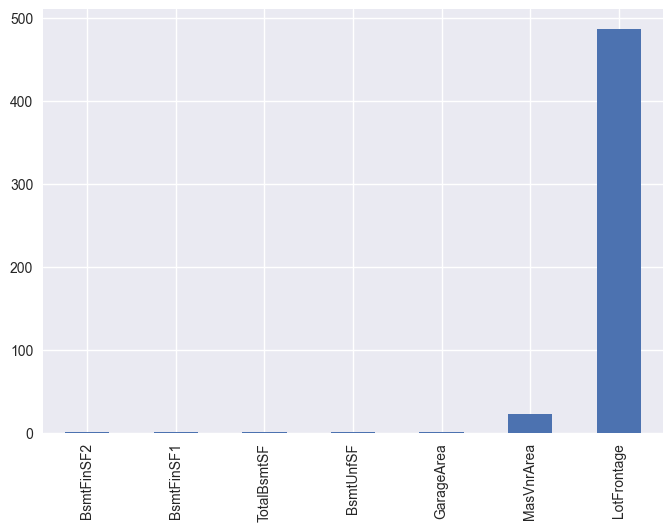

In [11]:
plot_missing(data_raw[quantitative])

Visualisation des données manquantes pour les variables qualitatives.

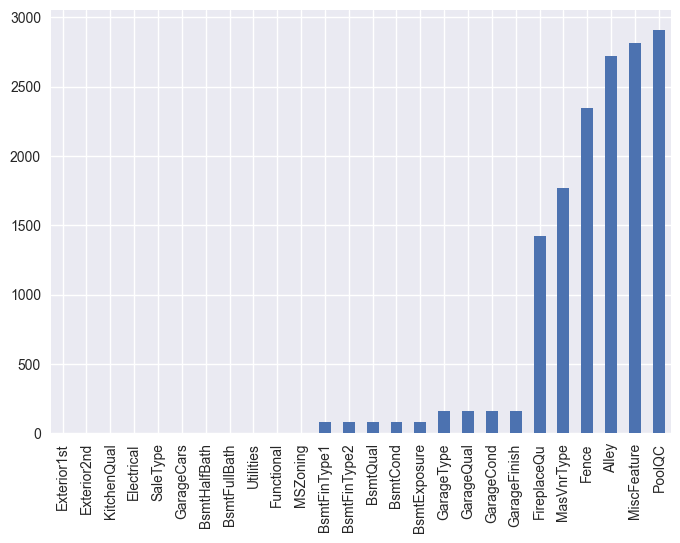

In [12]:
plot_missing(data_raw[qualitative])

Cette méthode générique permet de traiter efficacement et uniformément les valeurs manquantes dans les variables qualitatives ou quantitatives en les remplaçant par une constante prédéfinie (0, "None", "Unknown", etc.).

In [13]:
def fill_missing_with_constant(data, columns, constant):
    
    data_clean = data.copy()
    
    for c in columns :
        
        if data_clean[c].isnull().any():
            data_clean[c] = data_clean[c].fillna(constant)
    
    return data_clean

Visualisation des données manquantes pour les dates.

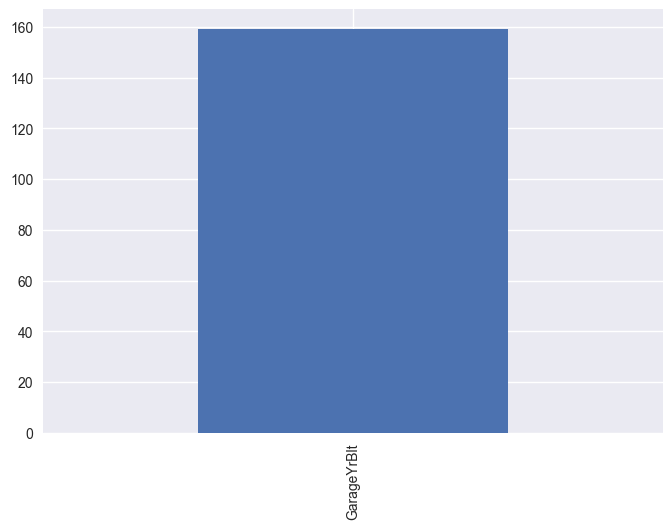

In [14]:
plot_missing(data_raw[date])

Certaines valeurs manquantes peuvent être déduites logiquement à partir d’autres colonnes du jeu de données.

C’est le cas, par exemple, de `GarageYrBlt`. S’il manque, il est raisonnable de supposer que le garage a été construit en même temps que la maison. On remplace donc la valeur manquante par `YearBuilt`. Cette méthode respecte la cohérence des données tout en évitant d’introduire des valeurs arbitraires.

In [16]:
def fill_missing_with_column(data, missing, column) :
    
    data_clean = data.copy()
    
    data_clean[missing] = np.where(data_clean[missing].isnull(), data_clean[column], data_clean[missing])
    
    return data_clean

## Transformation des dates

Les variables comme `YearBuilt`, `YearRemodAdd`, ou `GarageYrBlt` doivent être transformées en durées pour être exploitables par les modèles. On calcule ainsi :
- Âge de la maison
- Temps écoulé depuis la rénovation
- Âge du garage

Cette transformation permet :
- d’extraire une information temporelle directement exploitable
- de standardiser les unités (toutes exprimées en années)

In [17]:
def compute_differences_to_year_sold(data) :
    
    data_clean = data.copy()
    
    data_clean['YearBuilt'] = data_clean['YrSold'] - data_clean['YearBuilt']
    data_clean['YearRemodAdd'] = data_clean['YrSold'] - data_clean['YearRemodAdd']
    data_clean['GarageYrBlt'] = data_clean['YrSold'] - data_clean['GarageYrBlt']
    
    return data_clean

## Nettoyage

La fonction `clean()` centralise toutes les étapes de prétraitement citées précédemment, en vue de les rendre cohérentes et prêtes pour la modélisation.

In [18]:
def clean(data) :
    data_clean = data.copy()
    
    # Traitement des valeurs manquantes
    data_clean = fill_missing_with_constant(data_clean, columns = quantitative, constant = 0)
    data_clean = fill_missing_with_constant(data_clean, columns = qualitative, constant = 'NA')
    data_clean = fill_missing_with_column(data_clean, missing = ['GarageYrBlt'], column = ['YearBuilt'])

    # Transformation des dates
    data_clean = compute_differences_to_year_sold(data_clean)
    
    return data_clean

# Modèle Baseline

Un modèle baseline est une première version simple d’un modèle de machine learning. Son objectif n’est pas d’atteindre une performance optimale, mais plutôt d’établir un point de comparaison pour évaluer les modèles plus complexes à venir. Il permet d’avoir une référence objective pour mesurer les gains réels apportés par des modèles avancés.

Dans notre cas, le modèle baseline sera une régression linéaire simple, entraînée sur un sous-ensemble réduit de variables.

## Sélection des paramètres - OPHELIE développement

Pour pouvoir effectuer une analyse de régression, notre jeu de données doit subir une nouvelle transformation. Il est surtout nécessaire de transformer les variables catégorielles en variables numériques.

Une astuce intéressante dans notre contexte consiste à remplacer chaque catégorie par la moyenne de la variable cible associée à cette catégorie. Cette transformation introduit naturellement une corrélation entre la nouvelle variable ainsi créée et la variable cible.

In [19]:
encoded = data_raw.copy()

for col in qualitative:
    if encoded[col].dtype == 'object' or col in encoded.select_dtypes(include='object').columns:
        means = encoded.groupby(col)['SalePrice'].mean()
        encoded[col] = encoded[col].map(means)

Cinq variables ont été séletionnées sur la base de leur corrélation linéaire avec la cible **log(`SalePrice`)**, mesurée via le coefficient de Pearson.

Une heatmap de corrélation a été utilisée pour éviter la multicolinéarité. Des variables très corrélées entre elles apporteraient peu d'information supplémentaire et pourraient nuire au modèle.

Top corrélations avec log(SalePrice) :
OverallQual     0.790982
Neighborhood    0.738630
GrLivArea       0.708624
ExterQual       0.690933
KitchenQual     0.675721
BsmtQual        0.673614
PoolQC          0.669814
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
Alley           0.534319
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
GarageFinish    0.516988
YearRemodAdd    0.507101
Foundation      0.506328
GarageYrBlt     0.486362
MasVnrArea      0.477493
Name: SalePrice, dtype: float64


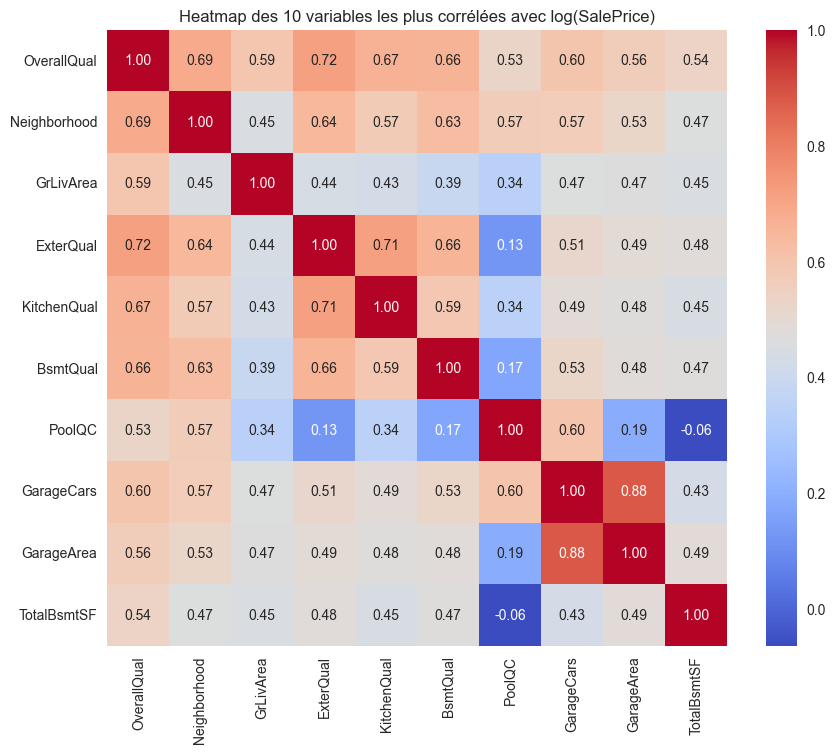

In [20]:
correlations = encoded.loc[train_raw.index].corr()['SalePrice'].drop('SalePrice').sort_values(ascending=False)

# Affichage des 20 variables les plus corrélées
print("Top corrélations avec log(SalePrice) :")
print(correlations.head(20))

# Heatmap de corrélation (top 10 variables)
top_features = correlations[0:10].index
plt.figure(figsize=(10, 8))
sns.heatmap(encoded.loc[train_raw.index, top_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Heatmap des 10 variables les plus corrélées avec log(SalePrice)")
plt.show()

**Liste des variables sélectionnées**:

| Variable       | Description                                                             | Corrélation avec log(`SalePrice`)  |
| -------------- | ----------------------------------------------------------------------- | -------------------------------- |
| `OverallQual`  | Évaluation générale de la qualité du bien                               | **+0.79** (la plus élevée)       |
| `Neighborhood` | Quartier, variable catégorielle la plus discriminante de sa catégorie   | **+0.74**                        |
| `GrLivArea`    | Surface habitable hors sous-sol, bon indicateur de la taille du bien    | **+0.70**                        |
| `TotalBsmtSF`  | Surface totale du sous-sol, complémentaire à `GrLivArea`                | **+0.61**                        |
| `YearBuilt`    | Année de construction, reflète l’ancienneté du bien                     | **-0.52** (corrélation négative) |

**Utilité de chaque variable**:
- OverallQual: Qualité globale
- Neighborhood: Emplacement
- GrLivArea: Taille / Surface
- TotalBsmtSF: Surface complémentaire
- YearBuilt: Axe temporel

**Remarque** : Les variables temporelles comme `YearBuilt` ont souvent une corrélation négative car des biens plus anciens ont généralement moins de valeur. Sauf dans certains quartiers historiques où ce n’est pas forcément le cas.


## Régression linéaire

L’objectif ici est de construire un modèle de régression linéaire simple, en utilisant les 5 variables sélectionnées précédemment. Cette approche permet de valider le prétraitement des données (nettoyage) et mesurer une performance de base.

In [21]:
# Nettoayage des données
data_clean = clean(data_raw)

# Variables sélectionnées
base = ['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'Neighborhood', 'YearBuilt']
x = data_clean[data_clean.index.isin(train_raw.index)][base].copy()
y = target.copy()

X_encoded = pd.get_dummies(x, columns=['Neighborhood'], drop_first=True)
X_array = sm.add_constant(X_encoded).astype(float)

# Création et entraînement du modèle de régression linéaire
model = sm.OLS(y, X_array)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.836
Model:                            OLS   Adj. R-squared:                  0.832
Method:                 Least Squares   F-statistic:                     259.9
Date:                Sun, 15 Jun 2025   Prob (F-statistic):               0.00
Time:                        13:17:11   Log-Likelihood:                 586.90
No. Observations:                1460   AIC:                            -1116.
Df Residuals:                    1431   BIC:                            -962.5
Df Model:                          28                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   10.9769 

### Assomptions du modèle

Voici les assomptions pour la régression linéaire, en indiquant avec quel graphique nous allons les tester :
- Linéarité de la relation entre les variables explicatives et la variable cible -> Residuals vs Fitted
- Les résultats sont normalements distribués autour de 0 -> Normal Q-Q Plot
- Homoscédasticité des résidus (variance constante) -> Scale-Location Plot
- Absence de points influents démesurés -> Residuals vs Leverage
- Absence d'outliers dans les résidus (erreurs extrêmes) -> visible dans plusieurs graphes, notamment Q-Q Plot et Cook’s Distance

In [23]:
def graph(formula, x_range, label=None):
    """
    Fonction utilitaire pour tracer des lignes de référence (Cook’s distance)
    """
    x = x_range
    y = formula(x)
    plt.plot(x, y, label=label, lw=1, ls='--', color='red')

def diagnostic_plots(X, y, model_fit=None):
    """
    Génère les 4 diagnostics visuels classiques d’un modèle de régression linéaire :
    - Residuals vs Fitted
    - Normal Q-Q
    - Scale-Location
    - Residuals vs Leverage
    """

    # Refit du modèle si aucun modèle n’est passé
    if not model_fit:
        model_fit = sm.OLS(y, sm.add_constant(X)).fit()

    # Création d’un DataFrame pour faciliter les plots
    dataframe = pd.concat([X, y], axis=1)

    # Récupération des métriques
    model_fitted_y = model_fit.fittedvalues                    # Valeurs prédites
    model_residuals = model_fit.resid                          # Résidus
    model_norm_residuals = model_fit.get_influence().resid_studentized_internal  # Résidus standardisés
    model_norm_residuals_abs_sqrt = np.sqrt(np.abs(model_norm_residuals))
    model_abs_resid = np.abs(model_residuals)
    model_leverage = model_fit.get_influence().hat_matrix_diag
    model_cooks = model_fit.get_influence().cooks_distance[0]

    # === 1. Residuals vs Fitted ===
    plt.figure()
    sns.residplot(x=model_fitted_y, y=dataframe.columns[-1], data=dataframe,
                  lowess=True, scatter_kws={'alpha': 0.5},
                  line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8})
    plt.title('Residuals vs Fitted')
    plt.xlabel('Fitted values')
    plt.ylabel('Residuals')
    # Annotation des 3 résidus absolus les plus grands
    abs_resid_top_3 = model_abs_resid.sort_values(ascending=False)[:3]
    for i in abs_resid_top_3.index:
        plt.annotate(i, xy=(model_fitted_y[i], model_residuals[i]))

    # === 2. Normal Q-Q Plot ===
    QQ = ProbPlot(model_norm_residuals)
    qq_plot = QQ.qqplot(line='45', alpha=0.5, color='#4C72B0', lw=1)
    qq_plot.axes[0].set_title('Normal Q-Q')
    qq_plot.axes[0].set_xlabel('Theoretical Quantiles')
    qq_plot.axes[0].set_ylabel('Standardized Residuals')
    # Annotation des 3 valeurs les plus éloignées
    abs_norm_resid_top_3 = np.abs(model_norm_residuals).argsort()[-3:][::-1]
    for r, i in enumerate(abs_norm_resid_top_3):
        qq_plot.axes[0].annotate(i, xy=(QQ.theoretical_quantiles[r], model_norm_residuals[i]))

    # === 3. Scale-Location Plot ===
    plt.figure()
    plt.scatter(model_fitted_y, model_norm_residuals_abs_sqrt, alpha=0.5)
    sns.regplot(x=model_fitted_y, y=model_norm_residuals_abs_sqrt,
                scatter=False, ci=False, lowess=True,
                line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8})
    plt.title('Scale-Location')
    plt.xlabel('Fitted values')
    plt.ylabel('√|Standardized Residuals|')
    for i in abs_norm_resid_top_3:
        plt.annotate(i, xy=(model_fitted_y[i], model_norm_residuals_abs_sqrt[i]))

    # === 4. Residuals vs Leverage ===
    plt.figure()
    plt.scatter(model_leverage, model_norm_residuals, alpha=0.5)
    sns.regplot(x=model_leverage, y=model_norm_residuals,
                scatter=False, ci=False, lowess=True,
                line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8})
    plt.title('Residuals vs Leverage')
    plt.xlabel('Leverage')
    plt.ylabel('Standardized Residuals')
    plt.xlim(0, max(model_leverage)+0.01)
    plt.ylim(-3, 5)
    # Annotation des points influents
    leverage_top_3 = np.argsort(model_cooks)[-3:][::-1]
    for i in leverage_top_3:
        plt.annotate(i, xy=(model_leverage[i], model_norm_residuals[i]))

    # === Lignes de Cook’s distance ===
    p = len(model_fit.params)  # nombre de paramètres
    graph(lambda x: np.sqrt((0.5 * p * (1 - x)) / x), np.linspace(0.001, max(model_leverage), 50), "Cook's 0.5")
    graph(lambda x: np.sqrt((1.0 * p * (1 - x)) / x), np.linspace(0.001, max(model_leverage), 50), "Cook's 1.0")
    plt.legend(loc='upper right')


c:\Data_science\venv\Lib\site-packages\statsmodels\graphics\gofplots.py:1041: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


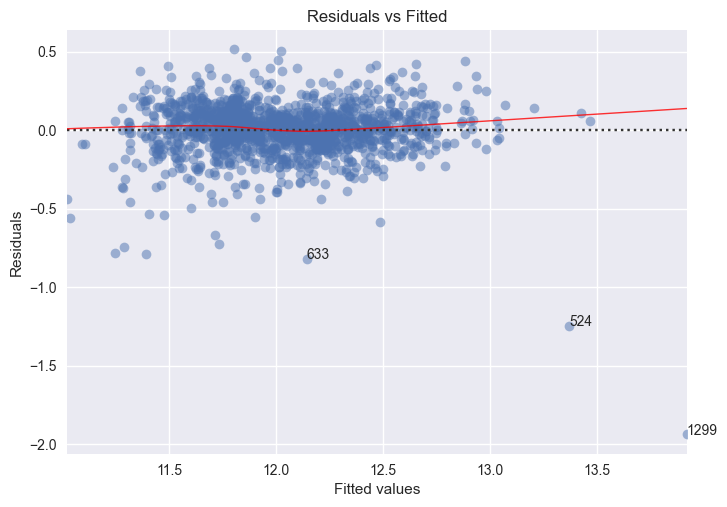

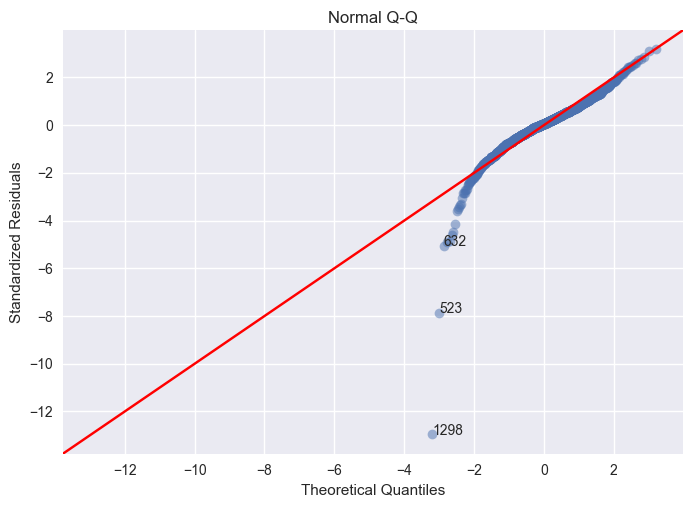

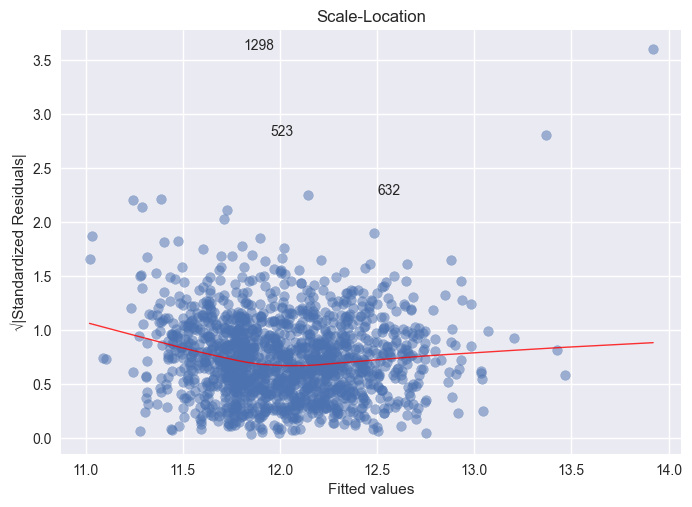

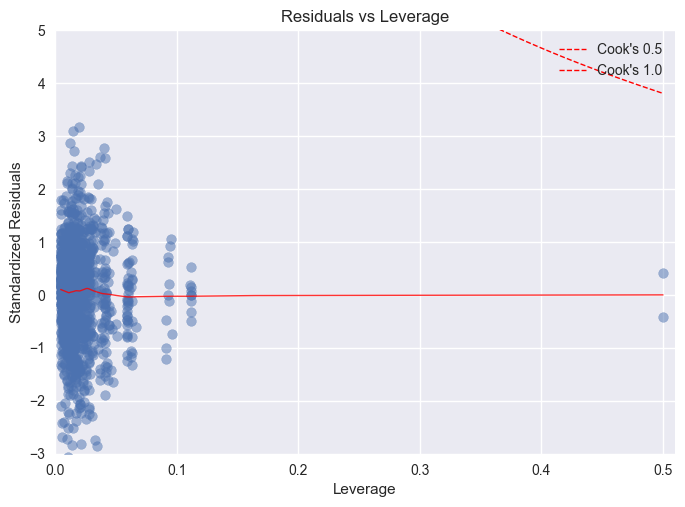

In [24]:
# Appel de la fonction de diagnostics
diagnostic_plots(X_encoded, y, model_fit=results)

### Vérification des hypothèses du modèle linéaire

Afin de s’assurer de la validité de notre régression linéaire, nous avons utilisé quatre graphiques diagnostics comme proposé ici: https://robert-alvarez.github.io/2018-06-04-diagnostic_plots/. 

#### 1. Residuals vs Fitted

Ce graphique montre que le modèle fonctionne globalement bien, sans erreur systématique.  On attend une bande horizontale et aléatoire autour de 0.

Légère perte de performance pour les maisons les plus chères, avec deux cas très isolés (`524` et `1299`), que le modèle surestime fortement.


La majorité des points sont bien centrés autour de zéro, sans motif clair. 


#### 2. Normal Q-Q Plot

Ce graphique teste si les résidus suivent une distribution normale. Si les résidus suivaient une loi normale parfaite, tous les points doivent s’aligner sur la diagonale rouge (y = x).



Une déviation claire est visible sur la gauche (valeurs très négatives). Plusieurs points s’éloignent significativement de la ligne de référence (`523`, `632`,`1298`), ce sont des biens qui ne sont pas représentatifs du reste du marché.

#### 3. Scale-Location Plot

Ce graphique sert à vérifier si les erreurs du modèle sont bien réparties quelle que soit la valeur prédite (homoscédasticité).
Il teste si le modèle est aussi fiable pour les maisons peu chères que pour les maisons très chères.
Le résultat montre que la variance est globalement constante.

Les mêmes points qu'avant (`523`, `632`,`1298`) ont des erreurs supérieures à la moyenne.

#### 4. Residuals vs Leverage (Cook's Distance)

Ce graphique permet de vérifier si certaines maisons ont une influence démesurée sur le modèle, ce qui pourrait fausser les résultats.
La grande majorité des observations ont un faible levier et des résidus modérés, ce qui confirme que les prédictions sont globalement représentatives du comportement du marché et ne reposent pas sur quelques cas particuliers.
 
2 points s’approchent de la limite critique (0.5), mais aucun ne dépasse franchement les seuils de Cook (0.5 ou 1.0).


### Identification des outliers 

L’analyse précédente a mis en évidence quelques points extrêmes, les observations `523`, `632`,`1298`, `524` et `1299`.

Certaines ventes ont été identifiées comme atypiques par https://jse.amstat.org/v19n3/decock/DataDocumentation.txt, notamment des biens avec une surface habitable (`GrLivArea`) supérieure à 4000 pieds carrés. Ces cas concernent souvent :
- des ventes partielles,
- ou des biens trop spécifiques pour être généralisables dans un modèle.

Nous avons combiné deux approches pour éliminer les points problématiques :

1. Le **critère métier** qui recommande de supprimer les maisons ayant plus de 4000 pieds carrés (`GrLivArea > 4000`). Ces ventes très atypiques ne sont pas représentatives du marché.

2. L’**analyse des résidus** via les graphiques de diagnostic précédemment réalisés, qui a fait ressortir les observations `523`, `632`,`1298`, `524` et `1299`.

En affichant les outliers identifiés, on se rend compte que `1299` et `524` sont déjà couverts par la 1ere approche (`GrLivArea > 4000`)

In [25]:
# Affichage des features de base pour les deux points problématiques identifiés
x.loc[[523, 524, 632, 1298, 1299]]

,OverallQual,GrLivArea,TotalBsmtSF,Neighborhood,YearBuilt
Id,,,,,
523,6,1664,1004.0,BrkSide,59
524,10,4676,3138.0,Edwards,0
632,8,1554,1554.0,NridgHt,1
1298,6,1072,547.0,Edwards,1
1299,10,5642,6110.0,Edwards,0


Index supprimés : [523, 524, 1298, 1299, 692, 632, 1183]


,OverallQual,GrLivArea,TotalBsmtSF,YearBuilt,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,...,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker
Id,,,,,,,,,,,,,,,,,,,,,
523,6,1664,1004.0,59,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
524,10,4676,3138.0,0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1298,6,1072,547.0,1,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1299,10,5642,6110.0,0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
692,10,4316,2444.0,13,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
632,8,1554,1554.0,1,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
1183,10,4476,2396.0,11,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False


                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.862
Model:                            OLS   Adj. R-squared:                  0.859
Method:                 Least Squares   F-statistic:                     318.1
Date:                Sun, 15 Jun 2025   Prob (F-statistic):               0.00
Time:                        13:22:04   Log-Likelihood:                 722.97
No. Observations:                1453   AIC:                            -1388.
Df Residuals:                    1424   BIC:                            -1235.
Df Model:                          28                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   10.8758 

c:\Data_science\venv\Lib\site-packages\statsmodels\graphics\gofplots.py:1041: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


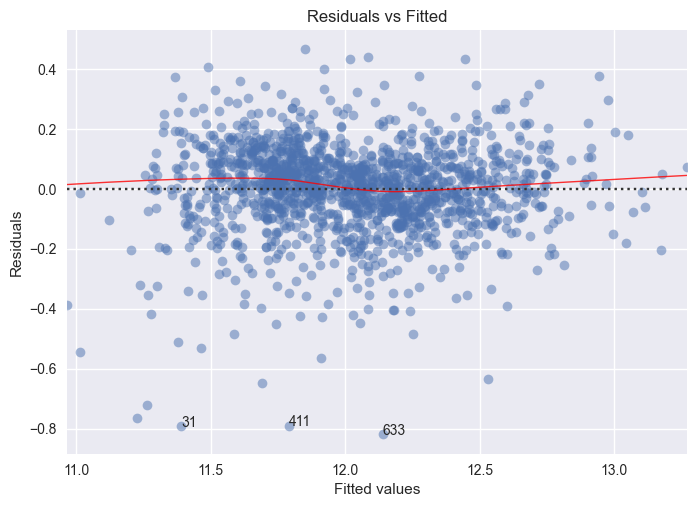

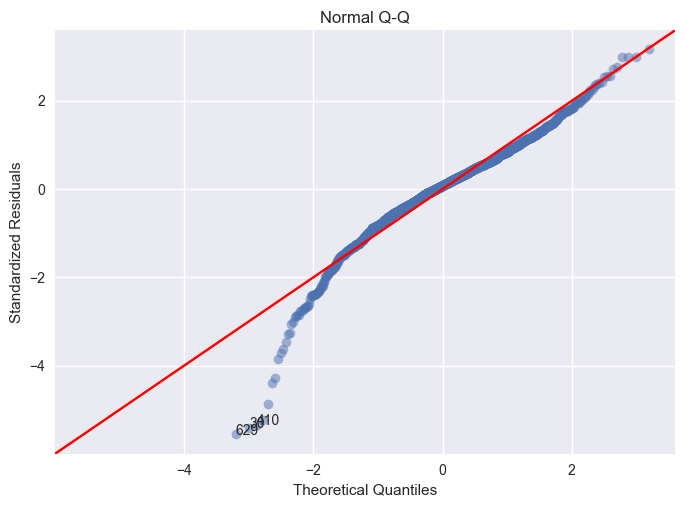

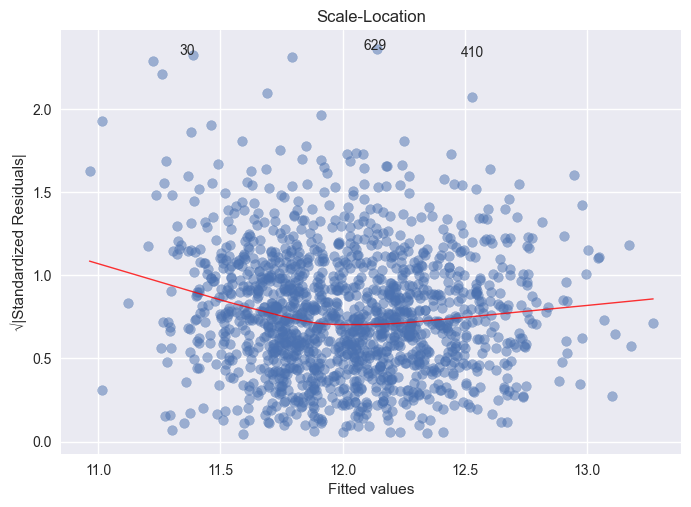

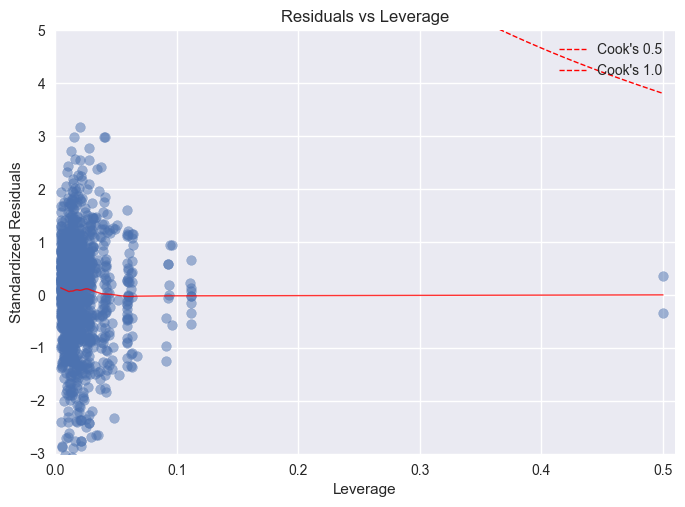

In [26]:
# Liste manuelle des index à supprimer (critère métier + résidus)
index_to_remove = X_encoded[(X_encoded['GrLivArea'] > 4000)].index.tolist()
index_to_remove += [523, 632, 1298]

# Supprimer les doublons au cas où
index_to_remove = list(set(index_to_remove))

# Afficher les lignes concernées (facultatif)
print("Index supprimés :", index_to_remove)
display(X_encoded.loc[index_to_remove])

# Filtrer les données
X_cleaned = X_encoded.drop(index=index_to_remove)
y_cleaned = y.drop(index=index_to_remove)

# Convertir en float pour statsmodels
X_cleaned_float = X_cleaned.astype(float)
y_cleaned_float = y_cleaned.astype(float)

# Modèle linéaire réentraîné
model_cleaned = sm.OLS(y_cleaned_float, sm.add_constant(X_cleaned_float))
results_cleaned = model_cleaned.fit()
print(results_cleaned.summary())

# Graphiques diagnostics
diagnostic_plots(X_cleaned_float, y_cleaned_float, model_fit=results_cleaned)

L’analyse des résidus et la suppression des outliers nous ont permis d’améliorer la robustesse de notre modèle linéaire baseline.
Ce dernier respecte maintenant les principales hypothèses pour une interprétation fiable des résultats.

## Explication OUTLIERS (après validation avec kiwi)
- Une fois outliers retirés, perfs moins bonnes sur kaggle. Expliquer peut être moins bonne gestion des cas extrèmes sur le dataset kaggle car pas habitué.

## Prédiction et soumission sur Kaggle

Une fois notre modèle entraîné (fit) sur les données d'entraînement, il est possible de l’utiliser pour prédire la variable cible sur le jeu de validation (`test.csv`), c’est-à-dire les maisons dont le prix de vente est inconnu.

**Important**: Les prédictions doivent être faites exclusivement sur le jeu de validation. Prédire sur les données d'entraînement n'a aucun intérêt, car le modèle a déjà vu ces données. Les résultats seraient biaisés et non représentatifs de la performance réelle du modèle.


In [24]:
# Nettoayage des données
x_test = data_clean[data_clean.index.isin(validation_raw.index)][base].copy()

# Encodage One-Hot de la variable catégorielle (Neighborhood) et alignement des colonnes
X_test_encoded = pd.get_dummies(x_test, columns=['Neighborhood'], drop_first=True)
feature_cols = [col for col in X_encoded.columns if col != 'const']
X_test_encoded = X_test_encoded.reindex(columns=feature_cols, fill_value=0)

# Ajout de l'intercept (constante)
X_test_array = sm.add_constant(X_test_encoded).astype(float)

# Prédictions sur les données de test
y_pred = results_cleaned.predict(X_test_array)

Les prédictions sont ensuite exportées au format .csv, conformément aux spécifications de la compétition. Ce fichier contiendra :

- une colonne `Id` correspondant aux identifiants du jeu de test
- une colonne `SalePrice` avec les prédictions transformées en valeurs réelles via l’inverse de la transformation logarithmique *(np.expm1())*.

Ce fichier peut ensuite être soumis sur la plateforme Kaggle pour obtenir un score de performance.

In [25]:
kaggle_submission = pd.DataFrame({
    'Id': x_test.index,
    'SalePrice': np.expm1(y_pred)
})
kaggle_submission.to_csv('Data/baseline.csv', index=False)

Ce modèle simple, basé sur 5 variables seulement, constitue une première approximation de la performance possible. Il obtient un score de `0.16472` sur la plateforme Kaggle, ce qui servira de référence pour évaluer les améliorations futures.

# Pipeline de prétraitement -> OPHELIE explications métier

Dans le cadre d'un projet de machine learning destiné à être déployé en production, il est essentiel de construire une pipeline de prétraitement modulaire et reproductible. Les points listés ci-dessous permettent de créer cette pipeline de prétraitement.

***Unification du traitement des données hétérogènes***

Le dataset contient trois grandes familles de variables :
- des numériques
- des catégorielles
- des temporelles

Chacune de ces familles nécessite un traitement spécifique. Grâce à `ColumnTransformer`, chaque type est traité par une pipeline dédiée, ce qui permet une séparation nette des logiques et une facilité de maintenance.

***Robustesse aux valeurs manquantes***

Le pipeline prévoit explicitement le traitement des valeurs manquantes :
- moyenne pour les numériques
- catégorisation "Missing" pour les qualitatives
- remplacement logique (par exemple GarageYrBlt → YearBuilt) pour les dates

Cela garantit que toutes les observations peuvent être traitées sans provoquer d’erreur, même en cas de données incomplètes en production.

***Encodage et mise à l’échelle adaptés aux modèles***

Les variables catégorielles sont encodées via `One-Hot Encoding`, ce qui permet leur exploitation par n'importe quel modèle, tout en évitant les erreurs en présence de nouvelles catégories *(handle_unknown='ignore')*.

Les variables numériques sont standardisées, ce qui est essentiel pour la stabilité et l’efficacité des modèles sensibles à l’échelle (régression linéaire par exemple).

***Nettoyage des données extrêmes (outliers)***

Certains points aberrants (maisons très grandes ou erreurs dans les prix par exemple) peuvent biaiser fortement les modèles linéaires. Leur suppression avant l'entraînement est donc une étape importante pour éviter un surapprentissage ou une mauvaise estimation des coefficients.

In [26]:
# ----------------------
# 1. Fonction de transformation des dates en années
# ----------------------

def compute_relative_dates(df):
    df = df.copy()
    df['YearsSinceBuilt'] = df['YrSold'] - df['YearBuilt']
    df['YearsSinceRemod'] = df['YrSold'] - df['YearRemodAdd']
    df['YearsSinceGarage'] = df['YrSold'] - df['GarageYrBlt'].fillna(df['YearBuilt'])
    return df[['YearsSinceBuilt', 'YearsSinceRemod', 'YearsSinceGarage']]


# Transformer scikit-learn compatible avec la nouvelle fonction date
date_transformer = Pipeline(steps=[
    ('relativedates', FunctionTransformer(compute_relative_dates, validate=False))
])

# ----------------------
# 2. Pipeline pour les colonnes numériques
# ----------------------

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# ----------------------
# 3. Pipeline pour les colonnes catégorielles
# ----------------------

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# ----------------------
# 4. Assemblage global via ColumnTransformer
# ----------------------

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, quantitative),
    ('cat', categorical_transformer, qualitative),
    ('dates', date_transformer, date)
], remainder='drop')  

# ----------------------
# 5. Préparation des données
# ----------------------

# Séparation train / test dans les données brutes
X_train = data_raw.loc[train_raw.index].copy()
X_test = data_raw.loc[validation_raw.index].copy()
y_train = target.copy()

# Suppression des outliers dans X_train et y_train
outliers_idx = train_raw.index[
    (train_raw['GrLivArea'] > 4000) |
    (train_raw.index.isin([523, 632, 1298]))
]

X_train = X_train.drop(index=outliers_idx)
y_train = y_train.drop(index=outliers_idx)

# ----------------------
# 6. Pipeline de prétraitement finale
# ----------------------

preprocessing_pipeline = Pipeline([
    ('preprocessor', preprocessor)
])

preprocessing_pipeline

print(f"Nombre d'observations avant suppression des outliers : {train_raw.shape[0]}")
print(f"Nombre d'observations après suppression : {X_train.shape[0]}")
print(f"Outliers supprimés : {len(outliers_idx)}")


Nombre d'observations avant suppression des outliers : 1460
Nombre d'observations après suppression : 1453
Outliers supprimés : 7


# Modèle 1 - Random Forest

In [27]:
# ----------------------
# Méthode pour optimiser le modèle RandomForest
# ----------------------
def random_forest_objective(trial, preprocessing_pipeline, X, y, cv, scoring):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 1200),
        'max_depth': trial.suggest_int('max_depth', 10, 40, log=True),
        'min_samples_split': trial.suggest_float('min_samples_split', 1e-5, 0.01, log=True),
        'min_samples_leaf': trial.suggest_float('min_samples_leaf', 1e-6, 1e-4, log=True),
        'max_features': trial.suggest_float('max_features', 0.1, 0.8)
    }
    model = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
    pipeline = Pipeline([
        ('preprocessing', preprocessing_pipeline),
        ('model', model)
    ])
    scores = cross_val_score(pipeline, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    return -scores.mean()

# Modèle 2 - Régression Lasso

In [28]:
# ----------------------
# Méthode pour optimiser le modèle Lasso
# ----------------------
def lasso_objective(trial, preprocessing_pipeline, X, y, cv, scoring):
    alpha = trial.suggest_float('alpha', 0.0005, 0.0008, log=True)
    model = Lasso(alpha=alpha, max_iter=10000, random_state=42)
    pipeline = Pipeline([
        ('preprocessing', preprocessing_pipeline),
        ('model', model)
    ])
    scores = cross_val_score(pipeline, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    return -scores.mean()

# Modèle 3 - Decision Tree

In [29]:
# ----------------------
# Méthode pour optimiser le modèle DecisionTree
# ----------------------
def decision_tree_objective(trial, preprocessing_pipeline, X, y, cv, scoring):
    
    params = {
        'max_depth': trial.suggest_int('max_depth', 10, 30, log=True),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20, log=True),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 10, 15, log=True)
    }

    model = DecisionTreeRegressor(**params, random_state=42)

    pipeline = Pipeline([
        ('preprocessing', preprocessing_pipeline),
        ('model', model)
    ])

    scores = cross_val_score(pipeline, X, y, cv=cv, scoring=scoring, n_jobs=-1)

    return -scores.mean()

# Modèle 4 - XGBoost

In [30]:
# ----------------------
# Méthode pour optimiser le modèle XGBoost
# ----------------------
def xgboost_objective(trial, preprocessing_pipeline, X, y, cv, scoring):
    params = {
        'eta': trial.suggest_float('eta', 0.01, 0.1),
        'n_estimators': trial.suggest_int('n_estimators', 500, 1200, log=True),
        'max_depth': trial.suggest_int('max_depth', 5, 15, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 5, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 0.3),
        'alpha': trial.suggest_float('alpha', 1e-6, 100, log=True),
        'lambda': trial.suggest_float('lambda', 1e-6, 100, log=True)
    }

    model = XGBRegressor(**params, objective='reg:squarederror', random_state=42, n_jobs=-1)

    pipeline = Pipeline([
        ('preprocessing', preprocessing_pipeline),
        ('model', model)
    ])

    scores = cross_val_score(pipeline, X, y, cv=cv, scoring=scoring, n_jobs=-1)

    return -scores.mean()

# Optimisation des modèles

Plutôt que de rechercher manuellement les meilleurs hyperparamètres pour chaque algorithme, une fonction générique a été mise en place `evaluate_and_optimize_models(...)` qui automatise l’optimisation grâce à la bibliothèque Optuna.

Cette fonction prend en entrée un dictionnaire associant des noms de modèles à leurs fonctions objective, dans lesquelles la logique d’optimisation spécifique est définie (paramètres testés, pipeline utilisée, etc.). Elle applique ensuite pour chaque modèle :
- une recherche intelligente sur l’espace des hyperparamètres
- une évaluation de chaque configuration par validation croisée (par défaut à 5 folds)
- l’affichage des meilleurs scores obtenus (RMSE) ainsi que des paramètres optimaux sélectionnés

Finalement, elle affiche une visualisation comparative des meilleures performances de chaque modèle via un diagramme en barres.

L’intérêt de cette approche est multiple :
- centraliser toute la logique d’optimisation dans une seule fonction, évitant ainsi la duplication de code
- permettre une exécution uniforme pour plusieurs modèles
- simplifier l’ajout ou la suppression d’un modèle à tester

In [31]:
def evaluate_and_optimize_models(model_configs, X, y, preprocessing_pipeline, cv=5, n_trials=30, scoring='neg_root_mean_squared_error'):
    """
    Optimise les modèles avec Optuna puis évalue leur performance via validation croisée.

    Paramètres:
    - model_configs: dict[str, callable], nom du modèle -> fonction objective(trial, pipeline, X, y)
    - X, y: données d'entrée brutes (non transformées)
    - preprocessing_pipeline: pipeline de prétraitement à injecter dans chaque modèle
    - cv: nombre de folds pour la cross-validation
    - n_trials: nombre d’essais pour Optuna
    - scoring: métrique (RMSE négatif par défaut)

    Retourne : dict avec les résultats RMSE moyens + std
    """

    results = {}

    for name, objective_func in model_configs.items():
        print(f"\nOptimisation pour : {name}")

        def wrapped_objective(trial):
            return objective_func(trial, preprocessing_pipeline, X, y, cv, scoring)

        study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42), study_name=name)
        study.optimize(wrapped_objective, n_trials=n_trials, show_progress_bar=True)

        best_score = study.best_value
        best_params = study.best_params
        print(f"✅ {name} | RMSE = {best_score:.4f} | Paramètres: {best_params}")
        print("------------------------------------")

        results[name] = (best_score, best_params, study)
    
    # Affichage graphique
    names = list(results.keys())
    means = [results[name][0] for name in names]

    plt.figure(figsize=(10, 5))
    plt.bar(names, means)
    plt.ylabel("Meilleur RMSE (CV)")
    plt.title("Comparaison des modèles optimisés")
    plt.xticks(rotation=45)
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

    return results

Une fois la fonction en place, il suffit de spécifier les modèles que l’on souhaite tester dans le dictionnaire `model_configs`. Chaque modèle est relié à une fonction objective dédiée, qui contient les instructions pour construire le pipeline, intégrer les hyperparamètres, et renvoyer le score de validation croisée.

L’appel à `evaluate_and_optimize_models(...)` déclenche alors l’optimisation pour chaque modèle, et enregistre les résultats utiles :
- le score RMSE optimal trouvé pendant la recherche
- les meilleurs hyperparamètres associés
- l’objet study Optuna pour un diagnostic visuel ou un suivi des essais

Ce mécanisme rend le processus reproductible, modulaire et traçable.

[I 2025-06-14 20:41:44,541] A new study created in memory with name: Random Forest



Optimisation pour : Random Forest


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2025-06-14 20:42:06,495] Trial 0 finished with value: 0.13308246980807006 and parameters: {'n_estimators': 762, 'max_depth': 38, 'min_samples_split': 0.001570297088405539, 'min_samples_leaf': 1.575132049977973e-05, 'max_features': 0.20921304830970558}. Best is trial 0 with value: 0.13308246980807006.
[I 2025-06-14 20:42:27,086] Trial 1 finished with value: 0.1345325129584367 and parameters: {'n_estimators': 609, 'max_depth': 10, 'min_samples_split': 0.003967605077052989, 'min_samples_leaf': 1.5930522616241016e-05, 'max_features': 0.5956508044572318}. Best is trial 0 with value: 0.13308246980807006.
[I 2025-06-14 20:42:38,498] Trial 2 finished with value: 0.13310330505831128 and parameters: {'n_estimators': 514, 'max_depth': 39, 'min_samples_split': 0.00314288089084011, 'min_samples_leaf': 2.6587543983272713e-06, 'max_features': 0.22727747704497045}. Best is trial 0 with value: 0.13308246980807006.
[I 2025-06-14 20:42:58,616] Trial 3 finished with value: 0.1323034699989884 and parame

[I 2025-06-14 21:27:33,956] A new study created in memory with name: Lasso


...

[I 2025-06-14 21:28:26,250] Trial 0 finished with value: 0.18491863810999712 and parameters: {'max_depth': 15, 'min_samples_split': 18, 'min_samples_leaf': 14}. Best is trial 0 with value: 0.18491863810999712.
[I 2025-06-14 21:28:26,440] Trial 1 finished with value: 0.18573031661370548 and parameters: {'max_depth': 19, 'min_samples_split': 2, 'min_samples_leaf': 10}. Best is trial 0 with value: 0.18491863810999712.
[I 2025-06-14 21:28:26,626] Trial 2 finished with value: 0.18534472810227928 and parameters: {'max_depth': 10, 'min_samples_split': 14, 'min_samples_leaf': 13}. Best is trial 0 with value: 0.18491863810999712.
[I 2025-06-14 21:28:26,771] Trial 3 finished with value: 0.18683922234555056 and parameters: {'max_depth': 22, 'min_samples_split': 2, 'min_samples_leaf': 15}. Best is trial 0 with value: 0.18491863810999712.
[I 2025-06-14 21:28:26,939] Trial 4 finished with value: 0.18573031661370548 and parameters: {'max_depth': 25, 'min_samples_split': 3, 'min_samples_leaf': 10}. Be

[I 2025-06-14 21:28:43,293] A new study created in memory with name: XGBoost


[I 2025-06-14 21:28:43,130] Trial 98 finished with value: 0.1853066188522058 and parameters: {'max_depth': 11, 'min_samples_split': 4, 'min_samples_leaf': 13}. Best is trial 0 with value: 0.18491863810999712.
[I 2025-06-14 21:28:43,290] Trial 99 finished with value: 0.18491863810999712 and parameters: {'max_depth': 24, 'min_samples_split': 5, 'min_samples_leaf': 14}. Best is trial 0 with value: 0.18491863810999712.
✅ Decision Tree | RMSE = 0.1849 | Paramètres: {'max_depth': 15, 'min_samples_split': 18, 'min_samples_leaf': 14}
------------------------------------

Optimisation pour : XGBoost


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2025-06-14 21:28:44,114] Trial 0 finished with value: 0.1548212733836638 and parameters: {'eta': 0.04370861069626263, 'n_estimators': 1150, 'max_depth': 11, 'min_child_weight': 8, 'subsample': 0.5780093202212182, 'colsample_bytree': 0.5779972601681014, 'gamma': 0.017425083650459836, 'alpha': 8.499808989183016, 'lambda': 0.06440507553993717}. Best is trial 0 with value: 0.1548212733836638.
[I 2025-06-14 21:28:44,649] Trial 1 finished with value: 0.11925167202226132 and parameters: {'eta': 0.0737265320016441, 'n_estimators': 509, 'max_depth': 15, 'min_child_weight': 9, 'subsample': 0.6061695553391381, 'colsample_bytree': 0.5909124836035503, 'gamma': 0.055021352956030146, 'alpha': 0.000271605114465485, 'lambda': 0.01577798188336503}. Best is trial 1 with value: 0.11925167202226132.
[I 2025-06-14 21:28:45,250] Trial 2 finished with value: 0.134511960292371 and parameters: {'eta': 0.048875051677790424, 'n_estimators': 645, 'max_depth': 10, 'min_child_weight': 5, 'subsample': 0.6460723242

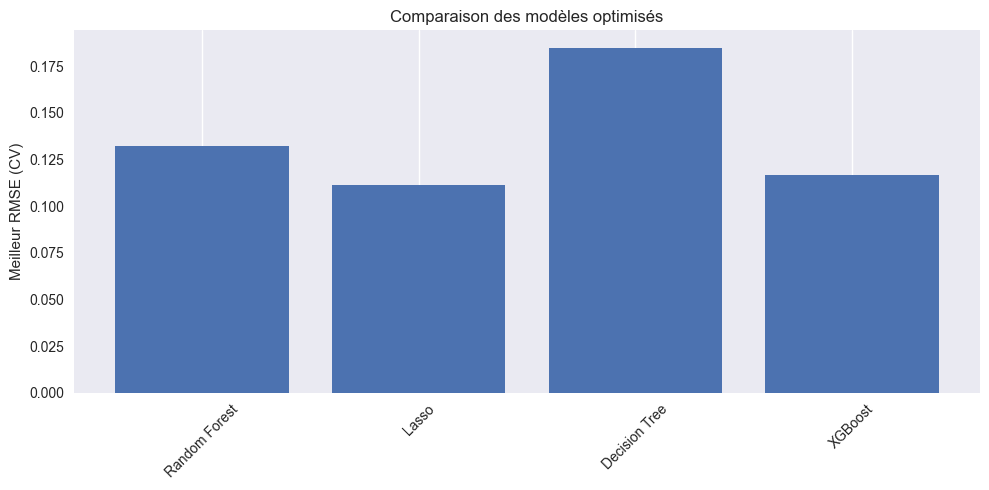

In [32]:
# ----------------------
# Exécution de l'optimisation et de l'évaluation des modèles
# ----------------------
model_configs = {
    'Random Forest': random_forest_objective,
    'Lasso': lasso_objective,
    'Decision Tree': decision_tree_objective,
    'XGBoost': xgboost_objective
}

results = evaluate_and_optimize_models(model_configs, X_train, y_train, preprocessing_pipeline, n_trials=100)

random_forest_best_params = results['Random Forest'][1]
lasso_best_params = results['Lasso'][1]
decision_tree_best_params = results['Decision Tree'][1]
xgboost_best_params = results['XGBoost'][1]

random_forest_study = results['Random Forest'][2]
lasso_study = results['Lasso'][2]
decision_tree_study = results['Decision Tree'][2]
xgboost_study = results['XGBoost'][2]

Après l’optimisation, il est important de réévaluer les modèles gagnants dans des conditions plus strictes, afin d’avoir une estimation plus stable et plus précise de leur performance réelle.

Pour cela, nous avons créé une fonction evaluate_final_cv(...) qui reprend :
- le modèle (classe + meilleurs hyperparamètres)
- la pipeline de prétraitement
- les données d’entraînement

Une évaluation par validation croisée à 10 folds est ensuite réalisée. Elle renvoie et affiche le **RMSE moyen** ainsi que son **écart-type**, ce qui permet de juger à la fois de la performance et de la stabilité du modèle.

In [33]:
# ----------------------
# Méthode d'évaluation finale avec une validation croisée de 10 "folds" 
# ----------------------
def evaluate_final_cv(model_name, model_class, best_params, preprocessing_pipeline, X, y, cv=10, scoring='neg_root_mean_squared_error'):
    model = model_class(**best_params, random_state=42)

    pipeline = Pipeline([
        ('preprocessing', preprocessing_pipeline),
        ('model', model)
    ])

    scores = cross_val_score(pipeline, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    mean_rmse = -scores.mean()
    std_rmse = -scores.std()

    print(f"\nÉvaluation finale (cv 10) pour {model_name} :")
    print(f"✅ RMSE moyen : {mean_rmse:.5f}")
    print(f"📏 Écart-type : {std_rmse:.5f}")
    print("------------------------------------")
    
    return mean_rmse, std_rmse

evaluate_final_cv("Random Forest", RandomForestRegressor, random_forest_best_params, preprocessing_pipeline, X_train, y_train)
evaluate_final_cv("Lasso", Lasso, lasso_best_params, preprocessing_pipeline, X_train, y_train)
evaluate_final_cv("Decision Tree", DecisionTreeRegressor, decision_tree_best_params, preprocessing_pipeline, X_train, y_train)
evaluate_final_cv("XGBoost", XGBRegressor, xgboost_best_params, preprocessing_pipeline, X_train, y_train)


Évaluation finale (cv 10) pour Random Forest :
✅ RMSE moyen : 0.13076
📏 Écart-type : -0.01405
------------------------------------

Évaluation finale (cv 10) pour Lasso :
✅ RMSE moyen : 0.10975
📏 Écart-type : -0.01462
------------------------------------

Évaluation finale (cv 10) pour Decision Tree :
✅ RMSE moyen : 0.17902
📏 Écart-type : -0.01711
------------------------------------

Évaluation finale (cv 10) pour XGBoost :
✅ RMSE moyen : 0.11809
📏 Écart-type : -0.01572
------------------------------------


(np.float64(0.11808560148480418), np.float64(-0.015719300401695932))

Les plages de recherche définies pour chaque hyperparamètre dans Optuna n'ont pas été choisies au hasard. Elles résultent d'analyses exploratoires itératives, réalisées à l’aide des graphiques `plot_slice` fournis par Optuna.

Ces visualisations permettent de comprendre l’influence de chaque hyperparamètre sur le score d’optimisation, et ainsi d’ajuster intelligemment les bornes des espaces de recherche pour les essais ultérieurs.

Pour alléger ce notebook, nous avons choisi de n’afficher que la dernière version des graphiques pour chaque modèle, correspondant aux réglages finaux retenus. Ces courbes offrent une vue synthétique de la sensibilité du modèle à ses hyperparamètres, et peuvent guider d'éventuelles itérations futures.

In [34]:
print("\nVisualisation des études Optuna pour Random Forest :")
plot_slice(random_forest_study).show()

print("\nVisualisation des études Optuna pour Lasso :")
plot_slice(lasso_study).show()

print("\nVisualisation des études Optuna pour Decision Tree :")
plot_slice(decision_tree_study).show()

print("\nVisualisation des études Optuna pour XGBoost :")
plot_slice(xgboost_study).show()


Visualisation des études Optuna pour Random Forest :



Visualisation des études Optuna pour Lasso :



Visualisation des études Optuna pour Decision Tree :



Visualisation des études Optuna pour XGBoost :


**Justification pour le Random Forest**
- `n_estimators` est augmenté (jusqu’à 1200) car le modèle bénéficie de forêts plus denses, tout en restant dans un temps de calcul acceptable.
- La plage de `max_depth` est restreinte entre 10 et 40 avec une échelle logarithmique. Cela permet d’éviter les arbres trop profonds et limiter l'impact des arbres profonds.
- `min_samples_split` et `min_samples_leaf` sont exprimés sous forme de proportion et en échelle log, afin de garantir une adaptabilité aux variations de taille du jeu de données et limiter l'impact des valeurs plus grandes.
- `max_features` est également exprimé comme ratio, ce qui facilite sa portabilité sur d'autres jeux de données.

**Justification pour le Lasso**

Le Lasso ne dépend que d’un seul hyperparamètre majeur : `alpha`, qui contrôle la force de la régularisation L1. Un `alpha` faible donne un modèle très flexible, qui risque de surajuster. Alors qu'un grand `alpha` offre une régularisation forte et donc un modèle très rigide (car de nombreux coefficients seront faibles). Comme nous avons un jeu de données moyen avec un nombre élevé de variables (365), un risque de surajustement existe. Plusieurs essais on permis de déterminer la plage actuelle, car elle présentait les meilleurs résultats.

Nous sommes conscients que certains modèles (comme Lasso ou Ridge) peuvent présenter un `second sweet spot` pour des valeurs extrêmes d’hyperparamètres, mais cette hypothèse ne sera pas explorée dans le cadre de ce projet.

**Justification pour le Decision Tree** :
 - `Max_depth` initialement large, resserrée entre 10 et 30
 - `Max_features`, log2 était sous-performant et a été retiré
 - Pour `min_samples_leaf`, les meilleures performances sont entre 10 et 15

**Justification pour XGBoost** : 
 - On a augmenté le nombre minimal d’arbres (`n_estimators`) car le modèle montrait de meilleures performances
 - On a limité la profondeur (`max_depth`) à 15 pour éviter la surcomplexité.
 - On a retiré les petites valeurs de `min_child_weight` et les grands `gamma`, qui tendaient à dégrader la performance 
 - Le learning rate (`eta`) est volontairement restreint à des valeurs faibles, car les meilleurs essais se concentrent autour de 0.01–0.05.

# Séletion du modèle - OPHELIE (last truc à faire)

Une fois le meilleur modèle identifié et optimisé (ici, le XGBoost), un nouvel entraîmenet complet est réalisé sur les données d’entraînement nettoyées (X_train) à l’aide des meilleurs hyperparamètres trouvés via Optuna.

Cette étape permet de soumettre officiellement le modèle sur la plateforme Kaggle, et d’obtenir un score de ...

In [35]:
xgboost_model = XGBRegressor(**xgboost_best_params, objective='reg:squarederror', random_state=42, n_jobs=-1)

model_pipeline = Pipeline([
    ('preprocessing_pipeline', preprocessing_pipeline),
    ('xgboost', xgboost_model)
    ])

model_pipeline.fit(X_train, y_train)

y_pred = model_pipeline.predict(X_test)

kaggle_submission = pd.DataFrame()
kaggle_submission['Id'] = X_test.index
kaggle_submission['SalePrice'] = np.expm1(y_pred)
kaggle_submission.to_csv('Data/xgboost.csv', index=False)

# Déploiement

Pour terminer, le modèle final est déployé via MLflow, un outil de gestion du cycle de vie des modèles de machine learning. L'objectif étant de versionner et stocker le modèle dans une plateforme dédiée.

Le serveur MLflow local est défini, ainsi que le nom d'expérimentation spécifique : *House_Price_Prediction*.

**Avant de lancer le code ci-dessous**, il faut démarrer le serveur local en exécutant la commande suivante :
- *mlflow server --host 127.0.0.1 --port 8080*

In [36]:
mlflow.set_tracking_uri(uri="http://127.0.0.1:8080")
mlflow.set_experiment("House_Price_Prediction")

<Experiment: artifact_location='mlflow-artifacts:/243767882592717077', creation_time=1749839495703, experiment_id='243767882592717077', last_update_time=1749839495703, lifecycle_stage='active', name='House_Price_Prediction', tags={}>

Ouverture d'une session MLflow dans laquelle sont enregistrés tous les éléments liés à l’entraînement du modèle sélectionné :
- log des hyperparamètres et de la métrique de performance issue d’Optuna
- ajout d'un tag descriptif
- déduction automatique de la signature d’entrée et de sortie du modèle
- enregistrement du modèle complet (pipeline + modèle) dans MLflow avec un nom versionné et un chemin d’accès

Cela permet de versionner et réutiliser le modèle dans un cadre de déploiement ou de monitoring.

In [37]:
with mlflow.start_run():
    mlflow.log_params(xgboost_best_params)
    mlflow.log_metric("accuracy", xgboost_study.best_value)

    mlflow.set_tag("Training Info", "XGBoost")

    signature = infer_signature(X_train, model_pipeline.predict(X_train))

    model_info = mlflow.sklearn.log_model(
        sk_model=model_pipeline,
        signature=signature,
        input_example=X_train,
        registered_model_name="XGBoost_model",
        artifact_path="XGBoost_model"
    )

c:\DataScience\data-science-project\.venv\Lib\site-packages\mlflow\types\utils.py:452: UserWarning:

Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.



Registered model 'XGBoost_model' already exists. Creating a new version of this model...
2025/06/14 21:32:01 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: XGBoost_model, version 6


🏃 View run defiant-snail-838 at: http://127.0.0.1:8080/#/experiments/243767882592717077/runs/449a948339ce4b7c8d47eb3fe178f0ac
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/243767882592717077


Created version '6' of model 'XGBoost_model'.


## Release management

### Plan de déploiementt 
Dans notre projet, nous avons développé un modèle de prédiction pour estimer le prix de biens immobiliers.
Cependant, il n’est pas nécessaire de mettre en place un système complexe de déploiement ou d'entraînement continu. Cela coûterait plus cher, ce serait plus compliqué à gérer, et surtout, cela ne répond pas à un besoin métier réel.

En effet, il n’y a pas d’obligation d’avoir le modèle actif 24h/24 ou de déployer sans interruption.
On peut se permettre que le modèle soit momentanément indisponible, par exemple pendant un week-end, le temps de le réentraîner et de le redéployer.

### Notre choix :
Nous allons donc réentraîner et redéployer le modèle une fois par trimestre (tous les 3 mois).
On prévoit une interruption complète du système pendant un week-end entier, ce qui nous laisse le temps nécessaire pour tout faire proprement.

### Justification
Équilibre entre coût et utilité :
Cela permet de garder un modèle à jour sans dépenser inutilement trop de ressources humaines ou techniques.

Responsabilité éthique :
Même si le modèle ne bouge pas tous les jours, il est important de le mettre à jour régulièrement pour détecter d’éventuelles évolutions anormales du marché, comme des phénomènes de ghettoïsation ou de gentrification mais aussi afin d'éviter que notre propre modèle en soit la cause, en surestimant ou en sous-estimant systématiquement certains quartiers ou types de biens.

Ce planning trimestriel de mise à jour est donc un bon compromis entre La simplicité technique, les contraintes budgétaires et une démarche responsable vis-à-vis des données et de l’impact sociétal du modèle.

# Conclusion
Dans ce projet, nous avons travaillé à l’intersection de deux mondes :

- la technique, représentée par le modèle de machine learning,

- le métier, incarné par les données brutes du marché immobilier et les besoins bancaires liés à l’octroi de prêts.

Mais ce qui fait vraiment la réussite du projet, ce n’est pas uniquement le modèle ou les données : c’est la capacité à relier les deux.

C’est pourquoi la phase de compréhension et de prétraitement des données a été un élément central. Grâce à la pipeline que nous avons construite, nous avons pu transformer les données brutes en informations exploitables par le modèle tout en respectant les contraintes et les logiques du métier bancaire.

Cette passerelle entre données métier et algorithmes techniques est ce qui permet d’avoir un système à la fois performant, fiable et pertinent dans un vrai contexte professionnel. La clé du succès d’un système d’IA appliqué à un domaine métier se trouve dans la qualité du lien entre les données du métier et les outils techniques, et que ce lien passe par un bon nettoyage, un bon encodage, et une vraie compréhension des variables.


## Ethique
Tout au long de ce travail nous avons travaillé en gardant en tête plusieurs préoccupations d'ordres éthiques:
- le phnénomène de refus automatique de prêt par un robot
- le phénomène de ghettoisation et de gentrification
- des potentielles stigmatisations ou discriminations raciales ou ethniques (dues à la défovarisation matérielle de certaines populations)